## Libs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold, HalvingRandomSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import randint, uniform
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## Carregar dataset pré-processado

In [3]:
# Carregar dataset pré-processado da Aula 2
path = "../data/raw/Telco_customer_churn_preprocessed.csv"

df = pd.read_csv(path)

# Garantir coluna alvo presente e binária (já tratada na Aula 2)
assert 'target' in df.columns, "Coluna 'target' não encontrada no dataset pré-processado."

# Remover colunas de metadados se existirem
for col in ['id', 'dataset']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print(f"Dataset shape (pré-processado): {df.shape}")
print("\nTarget (0=Sem churn, 1=Com churn):")
print(df['target'].value_counts())

df.head()

Dataset shape (pré-processado): (7043, 31)

Target (0=Sem churn, 1=Com churn):
target
0    5174
1    1869
Name: count, dtype: int64


,zip_code,monthly_charges,target,average_monthly_spend,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_No phone service,...,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,90003,53.85,1,54.075000,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,70.70,1,75.825000,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,99.65,1,102.562500,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,90010,104.80,1,108.787500,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,90015,103.70,1,102.781633,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


## Seleção de Features
Selecione as features mais relevantes

In [4]:
# Dividir dados (dataset já numérico, sem OHE adicional)
y = df['target']
X = df.drop(columns=['target'])
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Seleção de features usando ANOVA F-value
selector_preview = SelectKBest(f_classif, k=min(25, X_train.shape[1]))
X_train_selected = selector_preview.fit_transform(X_train, y_train)

X_test_selected = selector_preview.transform(X_test)

selected_mask = selector_preview.get_support()
selected_features = [name for name, keep in zip(feature_names, selected_mask) if keep]
print(f"\nFeatures selecionadas ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")


Features selecionadas (25):
1. monthly_charges
2. average_monthly_spend
3. senior_citizen_Yes
4. partner_Yes
5. dependents_Yes
6. internet_service_Fiber optic
7. internet_service_No
8. online_security_No internet service
9. online_security_Yes
10. online_backup_No internet service
11. online_backup_Yes
12. device_protection_No internet service
13. device_protection_Yes
14. tech_support_No internet service
15. tech_support_Yes
16. streaming_tv_No internet service
17. streaming_tv_Yes
18. streaming_movies_No internet service
19. streaming_movies_Yes
20. contract_One year
21. contract_Two year
22. paperless_billing_Yes
23. payment_method_Credit card (automatic)
24. payment_method_Electronic check
25. payment_method_Mailed check


## Treinamento de diferentes algoritmos

### Passo a passo para o treinamento
1. Definimos um dicionário com os modelos que queremos comparar.
2. Montamos um Pipeline simples que inclui StandardScaler apenas quando o algoritmo é sensível à escala (como o SVM).
3. Treinamos cada modelo com os dados de treino e avaliamos no conjunto de teste.
4. Consolidamos as métricas em uma tabela para facilitar a comparação inicial.

In [5]:
# Comparação inicial entre diferentes algoritmos de classificação
model_configs = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

trained_models = {}
results = []

for model_name, estimator in model_configs.items():
    steps = []
    if model_name == "Support Vector Machine":
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = np.nan
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    elif hasattr(pipeline, "decision_function"):
        y_scores = pipeline.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_scores)

    print(f"=== {model_name} ===")
    print(f"Acurácia no conjunto de teste: {accuracy:.3f}")
    print(classification_report(y_test, y_pred, target_names=["Sem churn", "Com churn"]))
    print("-" * 70)

    trained_models[model_name] = pipeline
    results.append({
        "Modelo": model_name,
        "Acurácia": accuracy,
        "Precisão": precision,
        "Recall": recall,
        "F1": f1,
        "ROC AUC": roc_auc,
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Acurácia", ascending=False).reset_index(drop=True).round(3)

=== Decision Tree ===
Acurácia no conjunto de teste: 0.720
              precision    recall  f1-score   support

   Sem churn       0.81      0.82      0.81      1035
   Com churn       0.47      0.45      0.46       374

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409

----------------------------------------------------------------------
=== Random Forest ===
Acurácia no conjunto de teste: 0.771
              precision    recall  f1-score   support

   Sem churn       0.82      0.88      0.85      1035
   Com churn       0.59      0.47      0.52       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.69      1409
weighted avg       0.76      0.77      0.76      1409

----------------------------------------------------------------------
=== Support Vector Machine ===
Acurácia no conjunto de teste: 0.784
              prec

,Modelo,Acurácia,Precisão,Recall,F1,ROC AUC
0,Support Vector Machine,0.784,0.606,0.527,0.564,0.795
1,Gradient Boosting,0.779,0.596,0.516,0.553,0.832
2,Random Forest,0.771,0.587,0.468,0.521,0.805
3,Decision Tree,0.720,0.471,0.455,0.463,0.635


## Tuning de hiperparametros
- Alvo: acurácia de teste > 0.86 (melhor que o modelo RandomForest sem otimização).
- Busca aleatória por 60 minutos apenas nos hiperparâmetros-chave do Random Forest.
- Em cada amostra: estimamos acurácia via CV estratificado (5-fold) e medimos acurácia no teste; mantemos o melhor por acurácia de teste.
- Ao final: reportamos se o alvo (>0.86) foi atingido e registramos melhor configuração e métricas no MLflow.

In [6]:
import time
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from scipy.stats import randint, uniform, loguniform

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# =========================
# Configurações
# =========================

TIME_LIMIT_MINUTES = 3
ROC_AUC_TARGET = 0.86

THRESHOLD_MIN = 0.10
THRESHOLD_MAX = 0.90
THRESHOLD_STEP = 0.01
THRESHOLD_OPTIMIZATION_METRIC = "F1"  # opções: "F1", "Recall", "Precisão", "Acurácia"

start_time = time.time()
deadline = start_time + TIME_LIMIT_MINUTES * 60

# =========================
# Pipeline base
# =========================

base_pipeline = Pipeline([
    ("selector", SelectKBest(score_func=f_classif, k="all")),
    ("model", GradientBoostingClassifier(random_state=42)),
])

# =========================
# Espaço de busca
# =========================

param_distributions = {
    "model__n_estimators": randint(50, 301),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_depth": randint(1, 6),
    "model__min_samples_split": randint(2, 200),
    "model__min_samples_leaf": randint(1, 100),
    "model__subsample": uniform(0.6, 0.4),
    "model__max_features": [None, "sqrt", "log2"],
}

sampler = ParameterSampler(
    param_distributions=param_distributions,
    n_iter=1_000_000,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best = {
    "params": None,
    "cv_roc_auc": -np.inf,
    "pipeline": None,
}

n_evaluated = 0

print(
    f"Iniciando tuning por até {TIME_LIMIT_MINUTES} min. "
    f"Alvo: ROC AUC CV > {ROC_AUC_TARGET}."
)

# =========================
# Tuning dos hiperparâmetros
# =========================

for i, params in enumerate(sampler, start=1):
    now = time.time()

    if now >= deadline:
        print("Tempo limite atingido; encerrando busca.")
        break

    pipeline = Pipeline([
        ("selector", SelectKBest(score_func=f_classif, k="all")),
        ("model", GradientBoostingClassifier(random_state=42)),
    ])

    pipeline.set_params(**params)

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    mean_cv = float(np.mean(cv_scores))

    if mean_cv > best["cv_roc_auc"]:
        pipeline.fit(X_train, y_train)

        best.update({
            "params": params,
            "cv_roc_auc": mean_cv,
            "pipeline": pipeline,
        })

        elapsed = now - start_time

        print(
            f"[{i}] Novo melhor | roc_auc_cv={mean_cv:.4f} | "
            f"t={elapsed/60:.1f}m | params={params}"
        )

    if i % 10 == 0:
        elapsed = now - start_time
        remaining = max(0.0, deadline - now)

        print(
            f"Iterações: {i} | melhor_roc_auc_cv={best['cv_roc_auc']:.4f} | "
            f"decorrido={elapsed/60:.1f}m | restante≈{remaining/60:.1f}m"
        )

    n_evaluated = i

# =========================
# Recupera melhor modelo
# =========================

best_model = best["pipeline"]

if best_model is None:
    best_model = base_pipeline.fit(X_train, y_train)

# =========================
# Tuning do threshold
# =========================

y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(
    THRESHOLD_MIN,
    THRESHOLD_MAX + THRESHOLD_STEP,
    THRESHOLD_STEP
)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results_df.sort_values(
    by=THRESHOLD_OPTIMIZATION_METRIC,
    ascending=False
).iloc[0]

best_threshold = float(best_threshold_row["Threshold"])
y_pred_final = (y_proba >= best_threshold).astype(int)

final_metrics = {
    "Threshold": best_threshold,
    "Acurácia": accuracy_score(y_test, y_pred_final),
    "Precisão": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

# Métricas com threshold padrão
y_pred_default = (y_proba >= 0.50).astype(int)

default_metrics = {
    "Threshold": 0.50,
    "Acurácia": accuracy_score(y_test, y_pred_default),
    "Precisão": precision_score(y_test, y_pred_default, zero_division=0),
    "Recall": recall_score(y_test, y_pred_default, zero_division=0),
    "F1": f1_score(y_test, y_pred_default, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

# =========================
# Resultados
# =========================

print("\nResumo da busca:")
print(f"Iterações avaliadas: {n_evaluated}")
print(f"Tempo total: {(time.time() - start_time) / 60:.1f} minutos")
print(f"Melhor ROC AUC CV: {best['cv_roc_auc']:.4f}")
print(f"ROC AUC teste: {final_metrics['ROC AUC']:.4f}")
print(f"Alvo ROC AUC CV > {ROC_AUC_TARGET}: {'atingido' if best['cv_roc_auc'] > ROC_AUC_TARGET else 'não atingido'}")

print(f"\nMelhor threshold por {THRESHOLD_OPTIMIZATION_METRIC}: {best_threshold:.2f}")

print("\nComparação threshold padrão vs otimizado:")
comparison_df = pd.DataFrame(
    [default_metrics, final_metrics],
    index=["Threshold padrão", "Threshold otimizado"]
).round(3)

display(comparison_df)

print("\nMatriz de confusão com threshold otimizado:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification report com threshold otimizado:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nTop 10 thresholds:")
display(
    threshold_results_df
    .sort_values(by=THRESHOLD_OPTIMIZATION_METRIC, ascending=False)
    .head(10)
    .round(3)
)

# =========================
# Registro no MLflow
# =========================

try:
    mlflow.set_experiment("aula3_time_budget_tuning")

    with mlflow.start_run(run_name="gb_hyperparameter_and_threshold_tuning"):
        if best["params"] is not None:
            for k, v in best["params"].items():
                mlflow.log_param(k, str(v))

        mlflow.log_param("selected_threshold", best_threshold)
        mlflow.log_param("threshold_optimization_metric", THRESHOLD_OPTIMIZATION_METRIC)
        mlflow.log_param("threshold_min", THRESHOLD_MIN)
        mlflow.log_param("threshold_max", THRESHOLD_MAX)
        mlflow.log_param("threshold_step", THRESHOLD_STEP)

        mlflow.log_metric("cv_roc_auc", float(best["cv_roc_auc"]))

        for k, v in final_metrics.items():
            mlflow.log_metric(k.replace(" ", "_").lower(), float(v))

        for k, v in default_metrics.items():
            mlflow.log_metric(f"default_{k.replace(' ', '_').lower()}", float(v))

        mlflow.sklearn.log_model(best_model, name="model")

    print("\nResultados registrados no MLflow.")

except Exception as e:
    print(f"\n[Aviso] Falha ao registrar no MLflow: {e}")

comparison_df

Iniciando tuning por até 3 min. Alvo: ROC AUC CV > 0.86.
[1] Novo melhor | roc_auc_cv=0.8443 | t=0.0m | params={'model__learning_rate': np.float64(0.03574712922600244), 'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 72, 'model__min_samples_split': 190, 'model__n_estimators': 70, 'model__subsample': np.float64(0.6624074561769746)}
[3] Novo melhor | roc_auc_cv=0.8460 | t=0.0m | params={'model__learning_rate': np.float64(0.09150423569345205), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 88, 'model__min_samples_split': 159, 'model__n_estimators': 87, 'model__subsample': np.float64(0.6003115063364057)}
[4] Novo melhor | roc_auc_cv=0.8466 | t=0.1m | params={'model__learning_rate': np.float64(0.2921573276549858), 'model__max_depth': 1, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 22, 'model__min_samples_split': 90, 'model__n_estimators': 98, 'model__subsample': np.float64(0.8099098641033556)}
[5] Novo melhor | 

,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
Threshold padrão,0.50,0.786,0.616,0.511,0.558,0.835
Threshold otimizado,0.24,0.731,0.496,0.829,0.621,0.835



Matriz de confusão com threshold otimizado:
[[720 315]
 [ 64 310]]

Classification report com threshold otimizado:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1035
           1       0.50      0.83      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.73      0.75      1409


Top 10 thresholds:


,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
14,0.24,0.731,0.496,0.829,0.621,0.835
25,0.35,0.771,0.553,0.706,0.620,0.835
24,0.34,0.769,0.550,0.709,0.619,0.835
23,0.33,0.765,0.543,0.719,0.619,0.835
15,0.25,0.735,0.500,0.807,0.618,0.835
26,0.36,0.771,0.556,0.693,0.617,0.835
16,0.26,0.737,0.503,0.797,0.616,0.835
13,0.23,0.721,0.485,0.840,0.615,0.835
22,0.32,0.758,0.532,0.725,0.614,0.835
18,0.28,0.743,0.511,0.767,0.613,0.835


2026/05/16 21:56:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Resultados registrados no MLflow.


,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
Threshold padrão,0.50,0.786,0.616,0.511,0.558,0.835
Threshold otimizado,0.24,0.731,0.496,0.829,0.621,0.835


In [22]:
# Qual é o maior recall onde conseguimos manter pelo menos 50% de precisão
threshold_results_df[
    threshold_results_df["Precisão"] >= 0.55
].sort_values(by="Recall", ascending=False).head(10)

,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
25,0.35,0.770759,0.553459,0.705882,0.620447,0.835081
26,0.36,0.771469,0.555794,0.692513,0.616667,0.835081
27,0.37,0.767211,0.551570,0.657754,0.600000,0.835081
28,0.38,0.772889,0.562791,0.647059,0.601990,0.835081
29,0.39,0.777147,0.571770,0.639037,0.603535,0.835081
30,0.40,0.779276,0.576642,0.633690,0.603822,0.835081
31,0.41,0.779276,0.578164,0.622995,0.599743,0.835081
32,0.42,0.778566,0.579082,0.606952,0.592689,0.835081
33,0.43,0.782825,0.588083,0.606952,0.597368,0.835081
34,0.44,0.784244,0.592105,0.601604,0.596817,0.835081


## Analise a matriz de confusão

- Quantos falsos negativos existem?
- Quantos falsos positivos?
- O modelo está enviesado?
- Ele quase não prevê positivos?
- Está “conservador”?

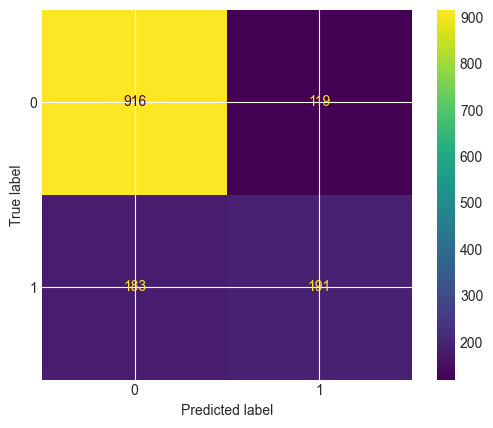

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## Analise as probabilidades do modelo

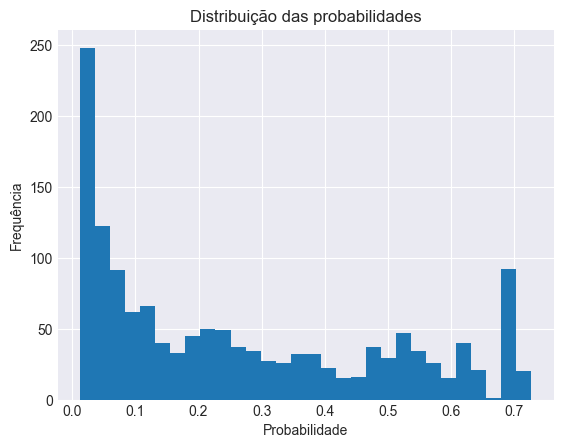

In [13]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=30)
plt.title("Distribuição das probabilidades")
plt.xlabel("Probabilidade")
plt.ylabel("Frequência")
plt.show()

## Analise Precision × Recall

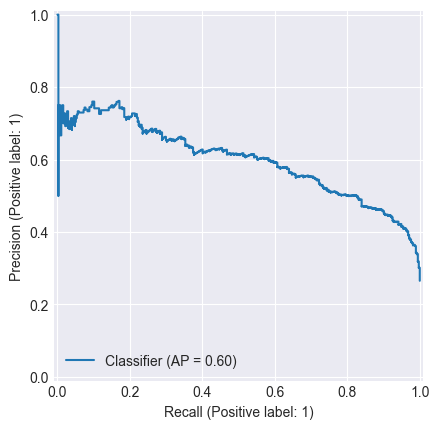

In [14]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.named_steps["model"].feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(15))

                             feature  importance
10      internet_service_Fiber optic    0.197018
28   payment_method_Electronic check    0.164781
6                     dependents_Yes    0.149757
25                 contract_Two year    0.148181
24                 contract_One year    0.133817
13               online_security_Yes    0.041526
0                           zip_code    0.036796
15                 online_backup_Yes    0.021641
19                  tech_support_Yes    0.019234
26             paperless_billing_Yes    0.017139
2              average_monthly_spend    0.015429
1                    monthly_charges    0.012438
5                        partner_Yes    0.006687
20  streaming_tv_No internet service    0.004471
11               internet_service_No    0.004332


## Importância de Features e Persistência

== Importância de Features do Melhor Modelo ==


,feature,importance
10,internet_service_Fiber optic,0.197018
28,payment_method_Electronic check,0.164781
6,dependents_Yes,0.149757
25,contract_Two year,0.148181
24,contract_One year,0.133817
13,online_security_Yes,0.041526
0,zip_code,0.036796
15,online_backup_Yes,0.021641
19,tech_support_Yes,0.019234
26,paperless_billing_Yes,0.017139


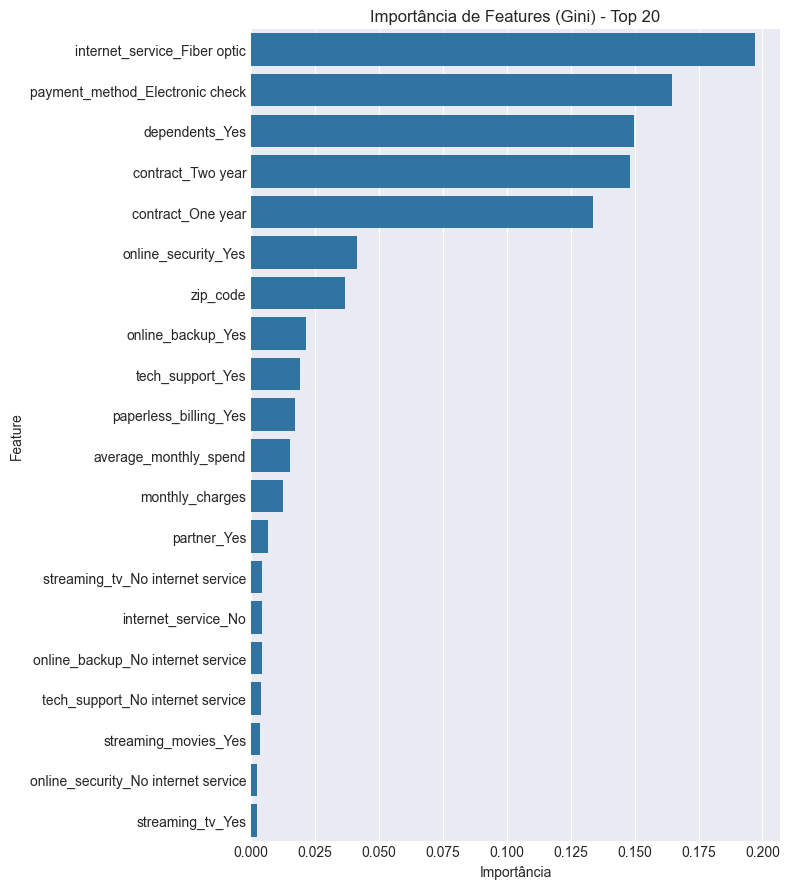

,feature,importance,std
10,internet_service_Fiber optic,0.030092,0.006032
6,dependents_Yes,0.023847,0.005590
25,contract_Two year,0.018879,0.004950
24,contract_One year,0.014691,0.004163
13,online_security_Yes,0.011001,0.003903
28,payment_method_Electronic check,0.006600,0.005049
19,tech_support_Yes,0.006388,0.004040
15,online_backup_Yes,0.005181,0.002312
26,paperless_billing_Yes,0.003478,0.005483
0,zip_code,0.002200,0.002186


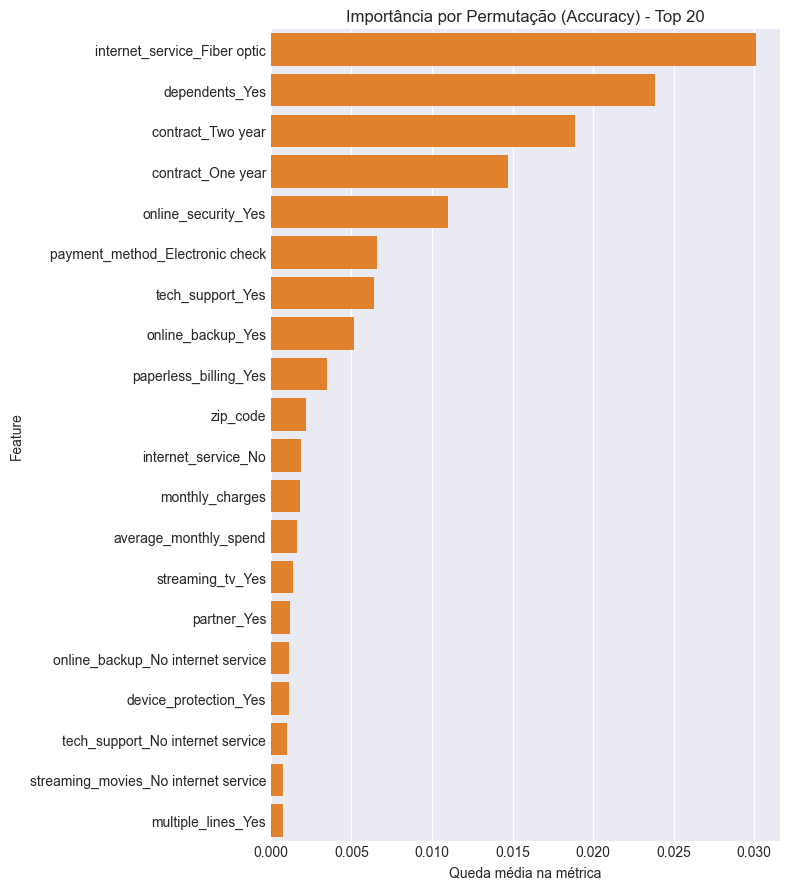

In [17]:
# Importância de features (Gini + Permutation) e persistência/log do melhor modelo
from datetime import datetime
import os
from sklearn.inspection import permutation_importance

print("== Importância de Features do Melhor Modelo ==")

# Garantias: execute a seção de tuning antes desta célula
assert "best_model" in globals(), "best_model não encontrado. Execute a seção de tuning antes."
assert "final_metrics" in globals(), "final_metrics não encontrado. Execute a seção de tuning antes."

# Extrair nomes de features utilizados pelo pipeline (após selector, se houver)
if hasattr(best_model, "named_steps") and "selector" in best_model.named_steps and hasattr(best_model.named_steps["selector"], "get_support"):
    mask = best_model.named_steps["selector"].get_support()
    feat_names_used = np.array(X_train.columns)[mask]
else:
    feat_names_used = np.array(X_train.columns)

# 1) Importância baseada em árvore (Gini)
model_step = best_model.named_steps["model"] if hasattr(best_model, "named_steps") and "model" in best_model.named_steps else best_model
tree_imp = getattr(model_step, "feature_importances_", None)

figs_to_log = []

if tree_imp is not None and len(tree_imp) == len(feat_names_used):
    imp_df = pd.DataFrame({"feature": feat_names_used, "importance": tree_imp}).sort_values("importance", ascending=False)
    display(imp_df.head(20))

    fig, ax = plt.subplots(figsize=(8, min(0.45*len(imp_df.head(20)), 10)))
    sns.barplot(data=imp_df.head(20), x="importance", y="feature", color="#1f77b4", ax=ax)
    ax.set_title("Importância de Features (Gini) - Top 20")
    ax.set_xlabel("Importância")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    figs_to_log.append(("feature_importance_gini_top20.png", fig))
    plt.show()
else:
    print("[Info] Modelo não expõe feature_importances_. Pulando gráfico Gini.")

# 2) Importância por permutação (Accuracy)
perm = permutation_importance(best_model, X_test, y_test, scoring="accuracy", n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": feat_names_used,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False)
display(perm_df.head(20))

fig2, ax2 = plt.subplots(figsize=(8, min(0.45*len(perm_df.head(20)), 10)))
sns.barplot(data=perm_df.head(20), x="importance", y="feature", color="#ff7f0e", ax=ax2)
ax2.set_title("Importância por Permutação (Accuracy) - Top 20")
ax2.set_xlabel("Queda média na métrica")
ax2.set_ylabel("Feature")
plt.tight_layout()
figs_to_log.append(("feature_importance_permutation_top20.png", fig2))
plt.show()

## Persistência do modelo para re-uso

In [19]:
# Persistência local com joblib
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

joblib_path = os.path.join(models_dir, f"best_model.joblib")
joblib.dump(best_model, joblib_path)
print(f"Modelo salvo via joblib em: {joblib_path}")

# Log no MLflow: abrir um novo run para registrar artefatos e o modelo salvo
mlflow.set_experiment("aula3_time_budget_tuning")
with mlflow.start_run(run_name="rf_importances_and_persistence"):
    # Parâmetros/metrics chave para rastreabilidade
    if 'best' in globals() and isinstance(best.get('params'), dict):
        for k, v in best["params"].items():
            mlflow.log_param(k, str(v))
    for k, v in final_metrics.items():
        if v is not None and not (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
            mlflow.log_metric(k.replace(" ", "_").lower(), float(v))

    # Logar figuras
    for fname, fobj in figs_to_log:
        try:
            mlflow.log_figure(fobj, fname)
        except Exception as e:
            print(f"[Aviso] Falha ao logar figura {fname}: {e}")

    # Logar o pipeline completo e o arquivo joblib como artifact
    mlflow.sklearn.log_model(best_model, artifact_path="sklearn_model")
    mlflow.log_artifact(joblib_path, artifact_path="joblib")

print("Concluído: importâncias, persistência (joblib) e log no MLflow.")

2026/05/16 22:20:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 22:20:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo salvo via joblib em: ../models/best_model.joblib
Concluído: importâncias, persistência (joblib) e log no MLflow.
